In [8]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# https://thewolfsound.com/bilinear-transform/


The bilinear transform is a method for designing digital filters from analog models. More precisely, it brings filters from the Laplace domain to the z-domain:

$$
H(s) \xrightarrow[\text{Transform}]{\text{Bilinear}} H(z)
$$

The following animation visualizes how the s-plane is morphed to the z-plane by bending the frequency axis:

In [12]:


fig, ax = plt.subplots()
ax.axis('equal')


ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

plt.fill_between([-1.2,0], [1.2,1.2],-1.2 ,  color='gray', alpha=0.2);


#plt.plot(-0.5,0,'xk',label='Pole');

plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)

plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc='lower right');



theta  = np.linspace( 0 , np.pi , 150 )
radius = 1
a = radius * np.cos( theta )
b = radius * np.sin( theta )

l, =  plt.plot( [0,0], [-10,10] , 'k--', linewidth=2)



x = np.arange(-2, 2, 0.01)
y1 = np.sin(2 * np.pi * x)-10

plt.legend(loc=(0.75,-0.05));
plt.xlim([-1.5,1.5]);
plt.ylim([-1.5,1.5]);


plt.close()


def animate(i):

    
    radius = 1+pow(2*i,4)
    
    xoff   = (radius)-(1-i)
    
    theta  = np.linspace( -np.pi , np.pi , 150 )
    
    a = radius * np.cos( theta )-xoff
    b = radius * radius* np.sin( theta )
    
    l.set_data(a,b)
    


    ax.fill_between(x, y1, 2,color='white')
    ax.fill_between(a, b, color='gray',alpha=0.3)

                 
    
rs  = np.linspace(1,0,100)

ani = matplotlib.animation.FuncAnimation(fig, animate, rs)


HTML(ani.to_jshtml())
HTML(ani.to_jshtml())



## 

natural logarithm maps the z-plane to the s-plane

for a given $H(s)$, we need to substitute $s$:

$$
\boxed{
s = \frac{2}{T} \frac{1-z^{-1}}{1+z^{-1}}
}
$$

with 

$$
T=\frac{1}{f_s}
$$


"piecewise constant magnitude response that approximates the magnitude response of an equivalent analog filter."

----

# Passive RC Lowpass Example

A simple example for the bilinear transform is the RC lowpass:

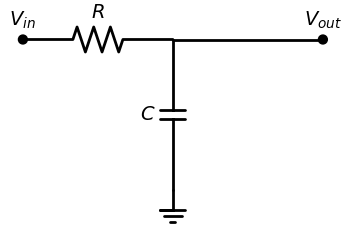

In [3]:
d = schem.Drawing()
d.add(e.Dot().label('$V_{in}$'))

d.add(e.Resistor().label('$R$'))
d.push() 

d.add(e.Capacitor().down().label('$C$'))

d.add(e.Ground())


d.pop()
d.add(e.Line().right())
d.add(e.Dot().label('$V_{out}$'))

d.draw()


**Transfer Function**

The resulting filter has a low pass characteristic with the following frequency response:



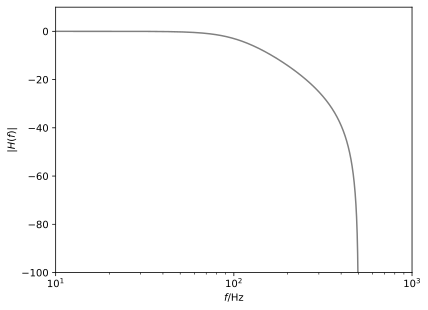

In [14]:

b, a = signal.butter(1, 100,fs=1000)

z,p, k = signal.butter(2, 100, output='zpk', fs=1000)

w, h = signal.freqz_zpk(z, p, k, fs=1000)

fig  = plt.figure()

ax   = fig.add_subplot(111)

ax.plot(w, 20 * np.log10(abs(h)),color = [0.5,0.5,0.5]);

ax.set_xscale('log')
ax.axis((10, 1000, -100, 10));

plt.xlabel('$f/\mathrm{Hz}$');
plt.ylabel('$|H(f)|$');
    



In the Laplace domain its transfer function is defined as (see [Laplace Section](https://ringbuffer.org/dsp/Digital_Filters/Laplace%20Transform/)):

$$
H(s) = \frac{\omega_c}{\omega_c + s} =  \frac{1}{1 + \frac{s}{\omega_c}} 
$$

$s$ represents the Laplace operator:

$$
s = \sigma + j \omega 
$$

The cutoff frequency of the passive filter is:

$$
\omega_c = \frac{1}{RC}
$$

**Substitution**

For a transform to the z-domain, the Laplace operator $s$ is subsstituted by the $z$ operator:

$$
s = \frac{2}{T}\frac{1-z^{-1}}{1+z^{-1}}
$$

$$
z = e^{sT}
$$


The following steps rearrange the resulting transfer function to be comprised of summands with the factor $z^{-n}$:

$$
\begin{align} %
%
H(z) = & \frac{\omega_c}{\omega_c + \frac{2}{T}  \frac{1-z^{-1}}{1+z^{-1}}} \\ 
%
= & \frac{\frac{T}{2} \omega_c}{ \frac{T}{2} \omega_c +   \frac{1-z^{-1}}{1+z^{-1}}} \\
% 
= & \frac{\frac{T}{2} \omega_c (1+ z^{-1})}{ \frac{T}{2} \omega_c (1+ z^{-1}) +   1-z^{-1}} \\
%
= & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{ \frac{T}{2} \omega_c (1+ z^{-1}) +   1-z^{-1}} \\
%
= & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{ \frac{T}{2} \omega_c + \frac{T}{2} \omega_c z^{-1} +  1-z^{-1}} \\
%  
= & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{1 + \frac{T}{2} \omega_c + (\frac{T}{2} \omega_c -1 )z^{-1}} \\
%
\end{align}
$$


For getting the coefficients of our digital filter, the transfer function needs to meet the following strucutre where $a_0=1$:


$$
H(z) = \frac{b_0 + b_1 z^{-1}}{1+ a_1 z^{-1}}
$$

This is achieved by expanding and simplifying:

$$
\begin{align} %
%
  H(z)  = & \frac{\frac{T}{2} \omega_c  + \frac{T}{2} \omega_c z^{-1}}{ \underbrace{ \mathbf{\color{gray} 1 + \frac{T}{2} \omega_c }}_{\text{must be 1}} + \left(\frac{T}{2} \omega_c -1 \right)z^{-1}} \\
 %
  = & \frac{\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c}  + \frac{ \frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} z^{-1}}{1+ \left(\frac{\frac{T}{2} \omega_c}{1 + \frac{T}{2} \omega_c} - \frac{1}{1 + \frac{T}{2} \omega_c} \right)z^{-1}} \\
 %
 = & \frac{\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c}  + \frac{ \frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} z^{-1}}{1+ \left(\frac{\frac{T}{2} \omega_c -1}{ \frac{T}{2} \omega_c + 1}  \right)z^{-1}} \\
\end{align}
$$

-----

## Coefficients

Following the above rearrangements, the coefficients can be directly extracted from the transfer funcion:

$$
H(z) = \frac{\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c}  + \frac{ \frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} z^{-1}}{1+ \left(\frac{\frac{T}{2} \omega_c -1}{ \frac{T}{2} \omega_c + 1}  \right)z^{-1}} = \frac{b_0 + b_1 z^{-1}}{1+ a_1 z^{-1}}
$$



$$ 
\begin{align}
\mathbf b_0 = & \frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} \\
\mathbf b_1 = &	\frac{\frac{T}{2} \omega_c}{ 1 + \frac{T}{2} \omega_c} \\
\mathbf a_1 = &	\frac{\frac{T}{2} \omega_c -1}{ \frac{T}{2} \omega_c + 1}   \\
\end{align}
$$

-----

## Filter Topology

The original dependence of the electrical components R and C is not important at this point.
However, with $\omega_c$ = $2 \pi f_0$ we can get the exact coefficients for any cutoff frequency
which can be used for the difference equation or applied in the following topology:

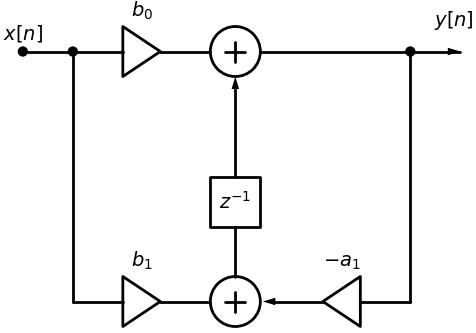

In [5]:

with schemdraw.Drawing() as d:

    d.config(unit=1, fontsize=14)
    
    e.Dot().label('$x[n]$')
    e.Line().right()
    e.Dot();
    
    d.push()
    
    e.Line().right()
    dsp.Amp().label('$b_0$')
    
    e.Line().right()

    s0 = dsp.Sum()
    
    d.pop()
    
    e.Line().down().length(5) # d='d',l=5)
    
    e.Line().right()
    dsp.Amp().label('$b_1$')
    e.Line().right()
    s1 = dsp.Sum()

    e.Line().at(s1.N).up() # d='u',xy=s1.N)

    z1 = dsp.Square().label('$z^{-1}$')    
    
    e.Arrow().up().length(2) # d='u',l=1.9)
    
    e.Line().at(s0.E).right().length(3) # d='r',xy=s0.E,l=3)
    
    d.push()
    
    e.Line().down().length(5) # , d='d',l=5)
    e.Line().left() # , d='l')
    dsp.Amp().label('$-a_1$') # ,botlabel='$-a_1$')
    e.Arrow().down().left(1.2) # , d='l',l=1.2)
    
    d.pop()
    e.Dot();
    e.Line().right() #, d='r')
    e.Arrowhead().label('$y[n]$')


    

    
    d.draw();

-----

## Poles and Zeros

NameError: name 'patches' is not defined

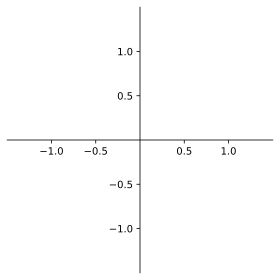

In [15]:
ax = plt.subplot(111)
ax.axis('equal')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)
    
uc = patches.Circle((0,0), radius=1, fill=False,
                        color='black', ls='dashed')
ax.add_patch(uc)


b, a, k = signal.butter(2, 490, output='zpk', fs=1000)
 
a[0] *= 2   
    
# zeros
z  = np.roots(b)
t1 = plt.plot(z.real, z.imag, 'ro', ms=10);

# poles
p  = np.roots(a)
t2 = plt.plot(p.real, p.imag, 'gx', ms=10)

plt.suptitle('Pole-Zero-Plot')
plt.xlabel('Real')
plt.ylabel('Imag')
ax.xaxis.set_label_coords(1,   0.5)
ax.yaxis.set_label_coords(0.5, 1)
 
